In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
network_df = pd.read_csv("ecocell_network.csv")

network_df.head()

,bs_id,x,y,cell_type,capacity_mbps,coverage_radius_km,baseline_power_w
0,BS00,0,0,urban,984.792314,0.837715,1435.786120
1,BS01,1,0,rural,887.566412,1.563692,967.693323
2,BS02,2,0,suburban,969.749471,1.177227,901.426410
3,BS03,3,0,suburban,947.413675,1.410285,1142.616932
4,BS04,4,0,urban,798.949989,1.889080,1489.955318


In [ ]:
print("Number of base stations:", len(network_df))

print("\nColumns:")
print(network_df.columns.tolist())

print("\nCell types:")
print(network_df["cell_type"].value_counts())

Number of base stations: 50

Columns:
['bs_id', 'x', 'y', 'cell_type', 'capacity_mbps', 'coverage_radius_km', 'baseline_power_w']

Cell types:
cell_type
urban       28
suburban    14
rural        8
Name: count, dtype: int64


In [ ]:
NUM_DAYS = 30
HOURS_PER_DAY = 24

time_index = pd.date_range(
    start="2026-01-01",
    periods=NUM_DAYS * HOURS_PER_DAY,
    freq="h"
)

print("Number of time steps:", len(time_index))
print("Start:", time_index[0])
print("End:", time_index[-1])

Number of time steps: 720
Start: 2026-01-01 00:00:00
End: 2026-01-30 23:00:00


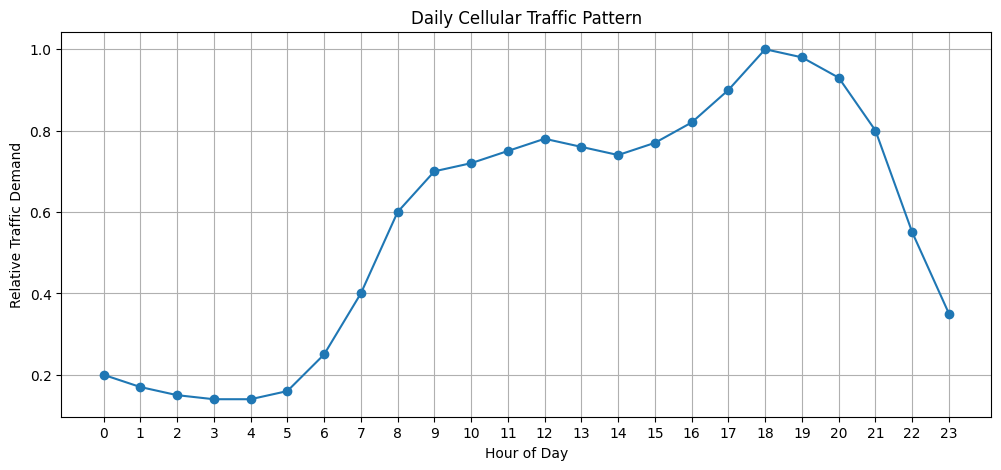

In [ ]:
hourly_pattern = np.array([
    0.20,  # 00:00
    0.17,  # 01:00
    0.15,  # 02:00
    0.14,  # 03:00
    0.14,  # 04:00
    0.16,  # 05:00
    0.25,  # 06:00
    0.40,  # 07:00
    0.60,  # 08:00
    0.70,  # 09:00
    0.72,  # 10:00
    0.75,  # 11:00
    0.78,  # 12:00
    0.76,  # 13:00
    0.74,  # 14:00
    0.77,  # 15:00
    0.82,  # 16:00
    0.90,  # 17:00
    1.00,  # 18:00
    0.98,  # 19:00
    0.93,  # 20:00
    0.80,  # 21:00
    0.55,  # 22:00
    0.35   # 23:00
])

plt.figure(figsize=(12, 5))

plt.plot(range(24), hourly_pattern, marker="o")

plt.title("Daily Cellular Traffic Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Relative Traffic Demand")
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [ ]:
def get_weekday_multiplier(timestamp):
    """
    Returns a multiplier based on whether the day
    is a weekday or weekend.
    """

    if timestamp.weekday() >= 5:
        return 0.80
    else:
        return 1.00

In [ ]:
cell_type_parameters = {
    "urban": {
        "traffic_multiplier": 1.30,
        "peak_hour": 18
    },

    "suburban": {
        "traffic_multiplier": 1.00,
        "peak_hour": 19
    },

    "rural": {
        "traffic_multiplier": 0.60,
        "peak_hour": 20
    }
}

In [ ]:
np.random.seed(42)

network_df["base_traffic_mbps"] = np.random.uniform(
    50,
    250,
    size=len(network_df)
)

network_df[[
    "bs_id",
    "cell_type",
    "capacity_mbps",
    "base_traffic_mbps"
]].head(10)

,bs_id,cell_type,capacity_mbps,base_traffic_mbps
0,BS00,urban,984.792314,124.908024
1,BS01,rural,887.566412,240.142861
2,BS02,suburban,969.749471,196.398788
3,BS03,suburban,947.413675,169.731697
4,BS04,urban,798.949989,81.203728
5,BS05,urban,960.937118,81.198904
6,BS06,urban,544.246251,61.616722
7,BS07,rural,597.991431,223.235229
8,BS08,suburban,522.613644,170.223002
9,BS09,suburban,662.665165,191.614516


In [ ]:
traffic_records = []

for timestamp in time_index:

    hour = timestamp.hour

    daily_factor = hourly_pattern[hour]

    weekday_factor = get_weekday_multiplier(timestamp)

    for _, bs in network_df.iterrows():

        cell_type = bs["cell_type"]

        type_params = cell_type_parameters[cell_type]

        type_factor = type_params["traffic_multiplier"]

        base_traffic = bs["base_traffic_mbps"]

        # Random variation
        noise = np.random.normal(
            loc=1.0,
            scale=0.08
        )

        traffic = (
            base_traffic
            * daily_factor
            * weekday_factor
            * type_factor
            * noise
        )

        # Traffic cannot be negative
        traffic = max(traffic, 0)

        traffic_records.append({
            "timestamp": timestamp,
            "bs_id": bs["bs_id"],
            "cell_type": cell_type,
            "traffic_mbps": traffic
        })

traffic_df = pd.DataFrame(traffic_records)

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps
0,2026-01-01,BS00,urban,34.394687
1,2026-01-01,BS01,rural,29.212211
2,2026-01-01,BS02,suburban,38.916347
3,2026-01-01,BS03,suburban,33.128630
4,2026-01-01,BS04,urban,18.615690


In [ ]:
NUM_BASE_STATIONS = len(network_df)
print("Number of traffic records:", len(traffic_df))
print("Expected records:", NUM_BASE_STATIONS * len(time_index))

Number of traffic records: 36000
Expected records: 36000


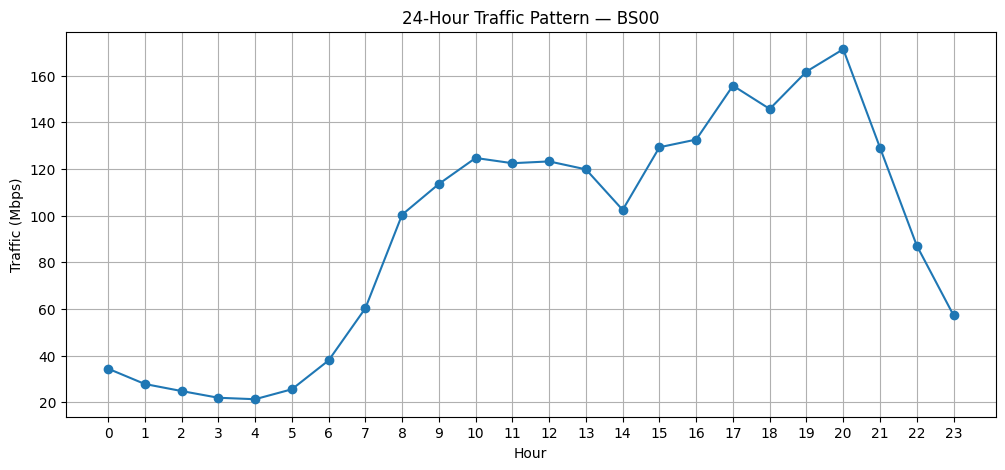

In [ ]:
sample_bs = "BS00"

sample_data = traffic_df[
    traffic_df["bs_id"] == sample_bs
]

first_day = sample_data[
    sample_data["timestamp"] < "2026-01-02"
]

plt.figure(figsize=(12, 5))

plt.plot(
    first_day["timestamp"].dt.hour,
    first_day["traffic_mbps"],
    marker="o"
)

plt.title(f"24-Hour Traffic Pattern — {sample_bs}")
plt.xlabel("Hour")
plt.ylabel("Traffic (Mbps)")
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [ ]:
cell_type_traffic = (
    traffic_df
    .groupby("cell_type")["traffic_mbps"]
    .mean()
)

print(cell_type_traffic)

cell_type
rural       75.254857
suburban    94.375130
urban       67.293399
Name: traffic_mbps, dtype: float64


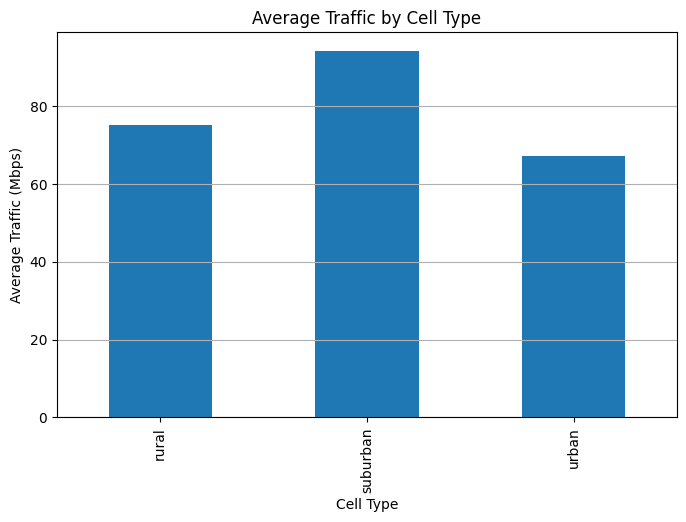

In [ ]:
cell_type_traffic.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Traffic by Cell Type")
plt.xlabel("Cell Type")
plt.ylabel("Average Traffic (Mbps)")
plt.grid(axis="y")

plt.show()

In [ ]:
# Average traffic generated by one active user
TRAFFIC_PER_USER_MBPS = 2.0

traffic_df["active_users"] = (
    traffic_df["traffic_mbps"] / TRAFFIC_PER_USER_MBPS
).round().astype(int)

traffic_df["active_users"] = traffic_df["active_users"].clip(lower=1)

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users
0,2026-01-01,BS00,urban,34.394687,17
1,2026-01-01,BS01,rural,29.212211,15
2,2026-01-01,BS02,suburban,38.916347,19
3,2026-01-01,BS03,suburban,33.128630,17
4,2026-01-01,BS04,urban,18.615690,9


In [ ]:
traffic_df = traffic_df.merge(
    network_df[["bs_id", "capacity_mbps"]],
    on="bs_id",
    how="left"
)

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps
0,2026-01-01,BS00,urban,34.394687,17,984.792314
1,2026-01-01,BS01,rural,29.212211,15,887.566412
2,2026-01-01,BS02,suburban,38.916347,19,969.749471
3,2026-01-01,BS03,suburban,33.128630,17,947.413675
4,2026-01-01,BS04,urban,18.615690,9,798.949989


In [ ]:
traffic_df["utilization"] = (
    traffic_df["traffic_mbps"]
    / traffic_df["capacity_mbps"]
)

traffic_df["utilization"] = traffic_df["utilization"].clip(
    lower=0,
    upper=1
)

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization
0,2026-01-01,BS00,urban,34.394687,17,984.792314,0.034926
1,2026-01-01,BS01,rural,29.212211,15,887.566412,0.032913
2,2026-01-01,BS02,suburban,38.916347,19,969.749471,0.040130
3,2026-01-01,BS03,suburban,33.128630,17,947.413675,0.034967
4,2026-01-01,BS04,urban,18.615690,9,798.949989,0.023300


In [ ]:
traffic_df["throughput_mbps"] = np.minimum(
    traffic_df["traffic_mbps"],
    traffic_df["capacity_mbps"]
)

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps
0,2026-01-01,BS00,urban,34.394687,17,984.792314,0.034926,34.394687
1,2026-01-01,BS01,rural,29.212211,15,887.566412,0.032913,29.212211
2,2026-01-01,BS02,suburban,38.916347,19,969.749471,0.040130,38.916347
3,2026-01-01,BS03,suburban,33.128630,17,947.413675,0.034967,33.128630
4,2026-01-01,BS04,urban,18.615690,9,798.949989,0.023300,18.615690


In [ ]:
traffic_df["packet_loss_rate"] = np.where(
    traffic_df["utilization"] < 0.80,
    np.random.uniform(0.001, 0.01, len(traffic_df)),
    np.random.uniform(0.01, 0.10, len(traffic_df))
)

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate
0,2026-01-01,BS00,urban,34.394687,17,984.792314,0.034926,34.394687,0.003310
1,2026-01-01,BS01,rural,29.212211,15,887.566412,0.032913,29.212211,0.009014
2,2026-01-01,BS02,suburban,38.916347,19,969.749471,0.040130,38.916347,0.002017
3,2026-01-01,BS03,suburban,33.128630,17,947.413675,0.034967,33.128630,0.001163
4,2026-01-01,BS04,urban,18.615690,9,798.949989,0.023300,18.615690,0.002295


In [ ]:
base_latency = 20  # milliseconds

traffic_df["latency_ms"] = (
    base_latency
    + 50 * (traffic_df["utilization"] ** 3)
    + np.random.normal(0, 2, len(traffic_df))
)

traffic_df["latency_ms"] = traffic_df["latency_ms"].clip(
    lower=5
)

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate,latency_ms
0,2026-01-01,BS00,urban,34.394687,17,984.792314,0.034926,34.394687,0.003310,18.827108
1,2026-01-01,BS01,rural,29.212211,15,887.566412,0.032913,29.212211,0.009014,20.964499
2,2026-01-01,BS02,suburban,38.916347,19,969.749471,0.040130,38.916347,0.002017,18.629819
3,2026-01-01,BS03,suburban,33.128630,17,947.413675,0.034967,33.128630,0.001163,23.756477
4,2026-01-01,BS04,urban,18.615690,9,798.949989,0.023300,18.615690,0.002295,21.127977


In [ ]:
np.random.seed(42)

spike_probability = 0.02

spike_mask = np.random.random(len(traffic_df)) < spike_probability

traffic_df["traffic_spike"] = spike_mask

traffic_df.loc[
    spike_mask,
    "traffic_mbps"
] *= np.random.uniform(
    1.5,
    2.5,
    spike_mask.sum()
)

print("Number of traffic spikes:", spike_mask.sum())

Number of traffic spikes: 695


In [ ]:
traffic_df["utilization"] = (
    traffic_df["traffic_mbps"]
    / traffic_df["capacity_mbps"]
)

traffic_df["throughput_mbps"] = np.minimum(
    traffic_df["traffic_mbps"],
    traffic_df["capacity_mbps"]
)

traffic_df["utilization"] = traffic_df["utilization"].clip(
    lower=0
)

traffic_df["active_users"] = (
    traffic_df["traffic_mbps"]
    / TRAFFIC_PER_USER_MBPS
).round().astype(int)

traffic_df["active_users"] = traffic_df["active_users"].clip(
    lower=1
)

In [ ]:
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         36000 non-null  datetime64[ns]
 1   bs_id             36000 non-null  object        
 2   cell_type         36000 non-null  object        
 3   traffic_mbps      36000 non-null  float64       
 4   active_users      36000 non-null  int64         
 5   capacity_mbps     36000 non-null  float64       
 6   utilization       36000 non-null  float64       
 7   throughput_mbps   36000 non-null  float64       
 8   packet_loss_rate  36000 non-null  float64       
 9   latency_ms        36000 non-null  float64       
 10  traffic_spike     36000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 2.8+ MB


In [ ]:
traffic_df.describe()

,timestamp,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate,latency_ms
count,36000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000
mean,2026-01-15 23:30:00,77.636739,38.816556,747.218791,0.107343,77.636739,0.005506,20.138511
min,2026-01-01 00:00:00,6.634526,3.000000,502.761059,0.007536,6.634526,0.001000,12.346367
25%,2026-01-08 11:45:00,30.511746,15.000000,599.357841,0.043101,30.511746,0.003271,18.788727
50%,2026-01-15 23:30:00,75.197968,38.000000,754.132106,0.102023,75.197968,0.005523,20.140403
75%,2026-01-23 11:15:00,112.616596,56.000000,885.635173,0.151524,112.616596,0.007759,21.488896
max,2026-01-30 23:00:00,540.163122,270.000000,993.443468,0.702919,540.163122,0.010000,28.482879
std,NaN,48.778469,24.389684,151.880908,0.070479,48.778469,0.002590,2.013141


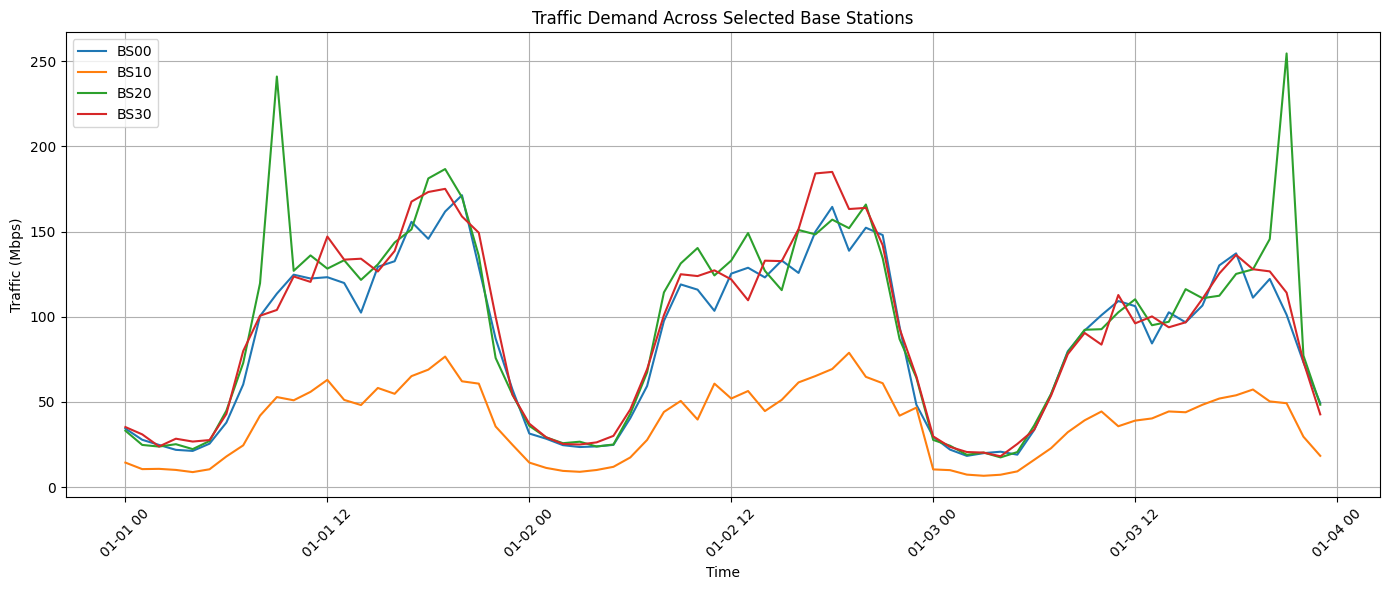

In [ ]:
sample_cells = ["BS00", "BS10", "BS20", "BS30"]

plt.figure(figsize=(14, 6))

for bs in sample_cells:

    data = traffic_df[
        traffic_df["bs_id"] == bs
    ].iloc[:72]

    plt.plot(
        data["timestamp"],
        data["traffic_mbps"],
        label=bs
    )

plt.title("Traffic Demand Across Selected Base Stations")
plt.xlabel("Time")
plt.ylabel("Traffic (Mbps)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
overloaded = traffic_df[
    traffic_df["utilization"] > 1
]

print(
    "Overloaded observations:",
    len(overloaded)
)

print(
    "Percentage overloaded:",
    len(overloaded) / len(traffic_df) * 100,
    "%"
)

Overloaded observations: 0
Percentage overloaded: 0.0 %


In [ ]:
traffic_df.to_csv(
    "ecocell_traffic.csv",
    index=False
)

print("Traffic dataset saved successfully!")
print("Rows:", len(traffic_df))
print("Columns:", len(traffic_df.columns))

Traffic dataset saved successfully!
Rows: 36000
Columns: 11
